In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
train_raw = pd.read_csv(r'C:\Users\LENOVO\Desktop\Traffic-Pattern-Forecasting\data\raw\train_aWnotuB.csv',
                     parse_dates=['DateTime'])

In [5]:
test_raw = pd.read_csv(r'C:\Users\LENOVO\Desktop\Traffic-Pattern-Forecasting\data\raw\datasets_8494_11879_test_BdBKkAj.csv',
                     parse_dates=['DateTime'])

In [6]:
def make_features(df, is_train=True):
    df = df.sort_values(['Junction', 'DateTime']).reset_index(drop=True)
 
    df['hour']       = df['DateTime'].dt.hour
    df['dayofweek']  = df['DateTime'].dt.dayofweek
    df['day']        = df['DateTime'].dt.day
    df['month']      = df['DateTime'].dt.month
    df['year']       = df['DateTime'].dt.year
    df['quarter']    = df['DateTime'].dt.quarter
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_night']   = df['hour'].isin(list(range(0, 6)) + list(range(22, 24))).astype(int)
    df['is_rush']    = df['hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']    = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dayofweek'] / 7)
 
    if is_train:
        for lag in [1, 2, 3, 24, 168]:
            df[f'lag_{lag}'] = df.groupby('Junction')['Vehicles'].shift(lag)
        for w in [3, 6, 24]:
            df[f'roll_mean_{w}'] = (df.groupby('Junction')['Vehicles']
                                      .transform(lambda x: x.shift(1).rolling(w).mean()))
            df[f'roll_std_{w}']  = (df.groupby('Junction')['Vehicles']
                                      .transform(lambda x: x.shift(1).rolling(w).std()))
        df = df.dropna().reset_index(drop=True)
 
    return df
 
train = make_features(train_raw, is_train=True)
test  = make_features(test_raw,  is_train=False)

In [7]:
train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'hour', 'dayofweek', 'day',
       'month', 'year', 'quarter', 'is_weekend', 'is_night', 'is_rush',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
       'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'roll_mean_3',
       'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_24',
       'roll_std_24'],
      dtype='str')

In [8]:
FEATURE_COLS = [
    'Junction',
    'hour', 'dayofweek', 'day', 'month', 'year', 'quarter',
    'is_weekend', 'is_night', 'is_rush',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168',
    'roll_mean_3', 'roll_mean_6', 'roll_mean_24',
    'roll_std_3',  'roll_std_6',  'roll_std_24',
]
TARGET = 'Vehicles'

In [9]:
val_start = '2017-05-01'
tr  = train[train['DateTime'] <  val_start]
val = train[train['DateTime'] >= val_start]
 
print(f"Train rows: {len(tr)} | Val rows: {len(val)}")
 
X_tr,  y_tr  = tr[FEATURE_COLS],  tr[TARGET]
X_val, y_val = val[FEATURE_COLS], val[TARGET]

Train rows: 41592 | Val rows: 5856


In [10]:
model = xgb.XGBRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    random_state     = 42,
    n_jobs           = -1,
    early_stopping_rounds = 50,
    eval_metric      = 'rmse',
)
 
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

[0]	validation_0-rmse:28.48006
[100]	validation_0-rmse:5.14322
[200]	validation_0-rmse:5.01869
[203]	validation_0-rmse:5.01504


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
val_preds = model.predict(X_val)
val_preds = np.clip(val_preds, 0, None)   # vehicles can't be negative
 
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
mae  = mean_absolute_error(y_val, val_preds)
print(f"\nVal RMSE: {rmse:.3f}")
print(f"Val MAE : {mae:.3f}")


Val RMSE: 4.982
Val MAE : 2.926


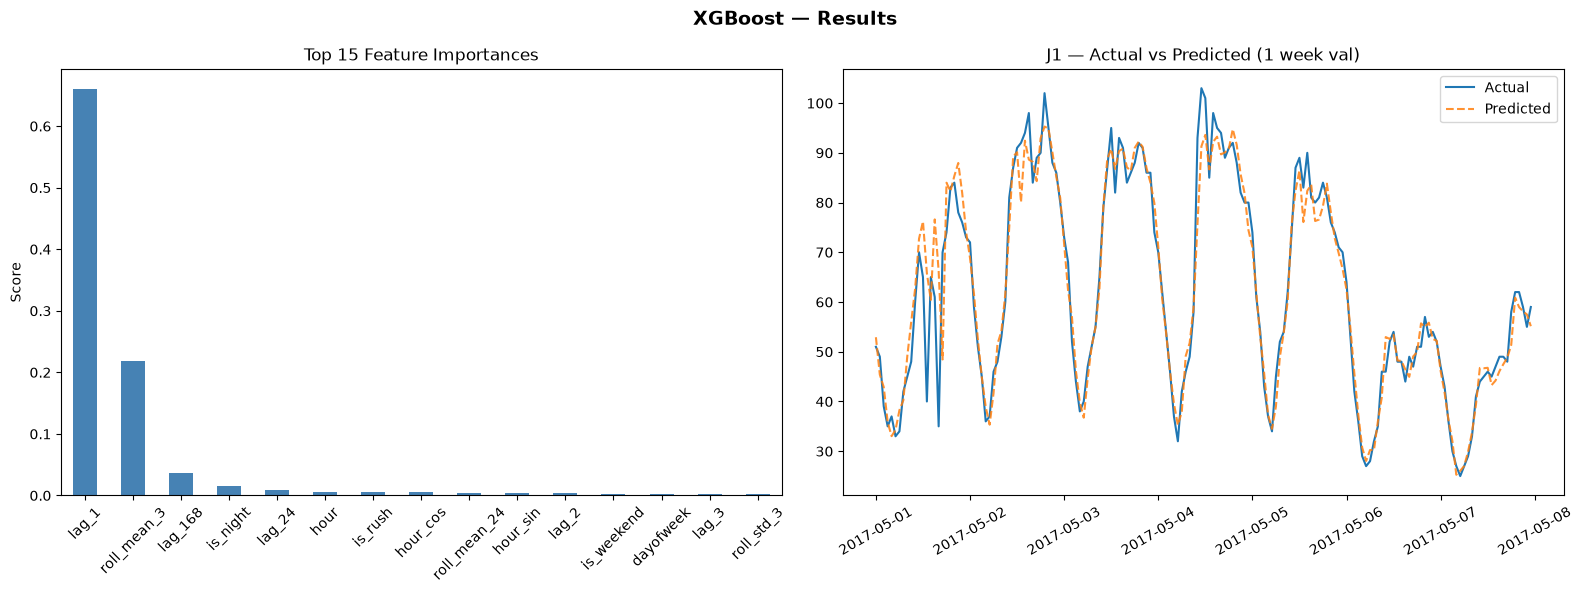

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost — Results', fontsize=14, fontweight='bold')
 
# Feature importance
imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
imp.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Feature Importances')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)
 
# Actual vs Predicted (Junction 1 sample)
j1_val = val[val['Junction'] == 1].copy()
j1_val['pred'] = model.predict(j1_val[FEATURE_COLS])
j1_val['pred'] = np.clip(j1_val['pred'], 0, None)
j1_sample = j1_val.head(7 * 24)   # 1 week
axes[1].plot(j1_sample['DateTime'], j1_sample[TARGET], label='Actual', linewidth=1.5)
axes[1].plot(j1_sample['DateTime'], j1_sample['pred'], label='Predicted',
             linewidth=1.5, linestyle='--', alpha=0.85)
axes[1].set_title('J1 — Actual vs Predicted (1 week val)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)
 
plt.tight_layout()
plt.savefig('xgb_results.png', dpi=130, bbox_inches='tight')
plt.show()

In [13]:
# Test has no lag features → use junction hourly averages from train as proxy
hourly_avg = (train.groupby(['Junction', 'hour'])['Vehicles']
                   .mean().reset_index()
                   .rename(columns={'Vehicles': 'lag_1'}))
 
test = test.merge(hourly_avg, on=['Junction', 'hour'], how='left')
# Fill all lag/roll cols with same hourly avg proxy
for col in FEATURE_COLS:
    if col not in test.columns:
        test[col] = test['lag_1']   # proxy
 
test_preds = model.predict(test[FEATURE_COLS])
test_preds = np.clip(test_preds, 0, None)
 
submission = pd.DataFrame({'ID': test_raw['ID'], 'Vehicles': test_preds.astype(int)})

In [14]:
submission.to_csv('submission_xgb.csv', index=False)

In [15]:
submission.head()

,ID,Vehicles
0,20170701001,38
1,20170701011,31
2,20170701021,29
3,20170701031,23
4,20170701041,20


~ END ~